<a href="https://colab.research.google.com/github/mdzubayereashraf/Ostad-AI-Engineering-Course-Assignments/blob/main/Assignmen_No_11(Diabetes_Prediction).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Diabetes Prediction Model**
`Objective:`

Training a Machine Learning classification model to predict whether a patient has diabetes based on medical attributes.

### **Importing All the Necessary Libraries**

In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder,LabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve,confusion_matrix, classification_report, RocCurveDisplay)
from sklearn.compose import ColumnTransformer



## **Part 1: Data Loading & Exploration**

### Loading dataset using Pandas

In [305]:
df = pd.read_csv("/content/drive/MyDrive/Kaggle Datasets/Diabetis Risk Prediction/diabetes_risk_prediction_dataset.csv")


### Showing first few rows

In [306]:
df.head()


,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,Normal
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,Obese
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,Obese
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,Overweight
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,Obese


### Check dataset shape

In [307]:
df.shape

(50000, 42)

### Cheeking Datatypes

In [308]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 42 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient_ID                  50000 non-null  int64  
 1   Age                         49503 non-null  float64
 2   Gender                      50000 non-null  object 
 3   Country                     50000 non-null  object 
 4   Height_cm                   47055 non-null  float64
 5   Weight_kg                   47038 non-null  float64
 6   BMI                         50000 non-null  float64
 7   Waist_Circumference_cm      50000 non-null  float64
 8   Blood_Glucose               49041 non-null  float64
 9   HbA1c                       48026 non-null  float64
 10  Fasting_Blood_Sugar         50000 non-null  float64
 11  Insulin_Level               50000 non-null  float64
 12  Blood_Pressure_Systolic     50000 non-null  int64  
 13  Blood_Pressure_Diastolic    500

### Dropping Unncessary Columns

In [309]:
df.drop(columns = ["Patient_ID", "Diabetes_Risk_Score", "AI_Health_Recommendation", "Doctor_Consultation_Needed", "BMI_CATEGORY"], inplace= True, errors= 'ignore')

In [310]:
df

,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,...,Family_History_Diabetes,Hypertension,Heart_Disease,Fatty_Liver,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk
0,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,149.5,...,Yes,No,Yes,Yes,No,Good,Retired,Rural,4.4,Moderate
1,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,199.3,...,Yes,No,Yes,Yes,Yes,Average,Government,Rural,2.1,High
2,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,219.6,...,Yes,No,No,Yes,No,Average,Government,Urban,2.8,High
3,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,217.7,...,Yes,Yes,No,No,No,Average,Business,Rural,1.5,High
4,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,153.5,...,No,Yes,Yes,Yes,Yes,Poor,Private,Rural,1.6,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,52.0,Female,United Kingdom,153.9,107.4,45.3,75.9,248.8,9.9,191.5,...,Yes,No,No,No,Yes,Average,Retired,Urban,3.5,High
49996,53.0,Male,United Kingdom,179.6,64.0,19.8,114.5,198.4,6.3,110.0,...,No,No,Yes,Yes,No,Average,Government,Urban,3.4,Moderate
49997,88.0,Male,Brazil,194.1,65.6,17.4,96.1,118.8,NaN,208.4,...,Yes,Yes,No,Yes,Yes,Poor,Retired,Urban,2.6,High
49998,23.0,Other,Bangladesh,168.0,73.9,26.2,131.4,139.5,9.2,84.7,...,No,No,No,Yes,Yes,Good,Private,Urban,2.7,Moderate


### Check for missing values

In [311]:
df.isnull().sum()

,0
Age,497
Gender,0
Country,0
Height_cm,2945
Weight_kg,2962
BMI,0
Waist_Circumference_cm,0
Blood_Glucose,959
HbA1c,1974
Fasting_Blood_Sugar,0


<Axes: >

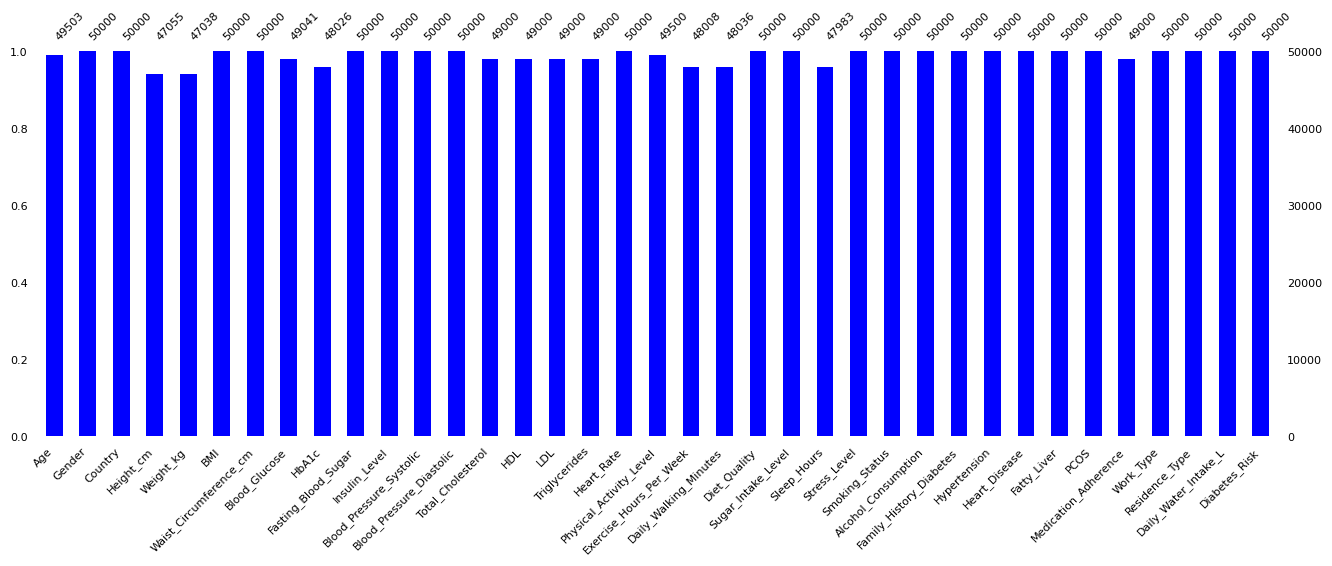

In [312]:
import missingno as msno
msno.bar(df, figsize=(16, 5), fontsize=8, color= "Blue")

<Axes: >

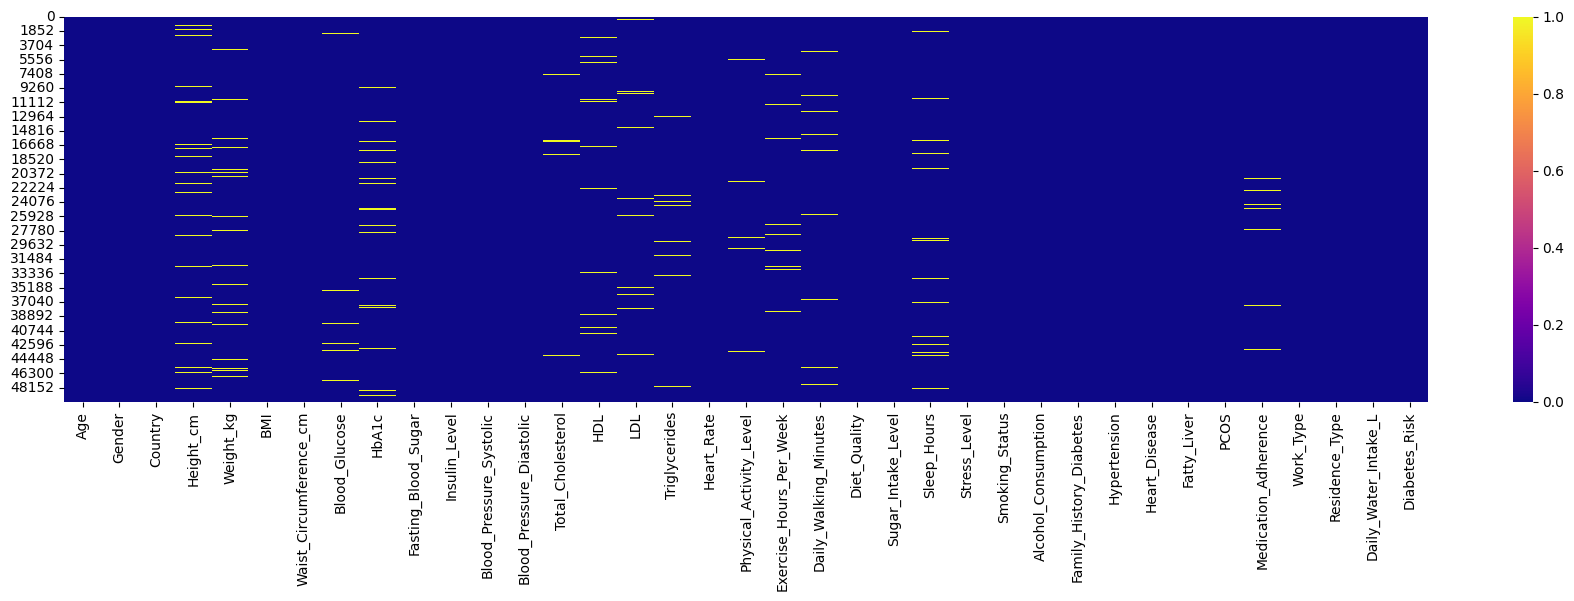

In [313]:
plt.figure(figsize=(22, 5))
sns.heatmap(df.isnull(),  cmap= 'plasma',cbar=True)


### Checking Zero filled columns that shouldn't be filled with Zeros

In [314]:
missing_numeric = df.select_dtypes(include='number').isnull().sum()
missing_numeric[missing_numeric > 0]

,0
Age,497
Height_cm,2945
Weight_kg,2962
Blood_Glucose,959
HbA1c,1974
Total_Cholesterol,1000
HDL,1000
LDL,1000
Triglycerides,1000
Exercise_Hours_Per_Week,1992


In [315]:
zero_as_missing = ["Height_cm","Weight_kg","BMI","Waist_Circumference_cm","Blood_Glucose","HbA1c","Fasting_Blood_Sugar","Insulin_Level","Blood_Pressure_Systolic",
                   "Blood_Pressure_Diastolic","Total_Cholesterol","HDL","LDL","Triglycerides", "Heart_Rate","Sleep_Hours","Daily_Water_Intake_L","Age"]



In [316]:
df[zero_as_missing].eq(0).sum()


,0
Height_cm,0
Weight_kg,0
BMI,0
Waist_Circumference_cm,0
Blood_Glucose,0
HbA1c,0
Fasting_Blood_Sugar,0
Insulin_Level,0
Blood_Pressure_Systolic,0
Blood_Pressure_Diastolic,0


No Zero-filled column is found

### Handling Missing Values

1.Handling numerical Columns first

In [317]:
#Checking numerical columns
numerical_columns = df.select_dtypes(include="number")
list(numerical_columns)


['Age',
 'Height_cm',
 'Weight_kg',
 'BMI',
 'Waist_Circumference_cm',
 'Blood_Glucose',
 'HbA1c',
 'Fasting_Blood_Sugar',
 'Insulin_Level',
 'Blood_Pressure_Systolic',
 'Blood_Pressure_Diastolic',
 'Total_Cholesterol',
 'HDL',
 'LDL',
 'Triglycerides',
 'Heart_Rate',
 'Exercise_Hours_Per_Week',
 'Daily_Walking_Minutes',
 'Sleep_Hours',
 'Daily_Water_Intake_L']

In [318]:
#Checking Numerical Missing Columns
missing_numeric = df.select_dtypes(include='number').isnull().sum()
missing_numeric


,0
Age,497
Height_cm,2945
Weight_kg,2962
BMI,0
Waist_Circumference_cm,0
Blood_Glucose,959
HbA1c,1974
Fasting_Blood_Sugar,0
Insulin_Level,0
Blood_Pressure_Systolic,0


In [319]:
#Filling missing values with their median
numeric_missing_columns = ["Age", "Height_cm", "Weight_kg", "Blood_Glucose", "HbA1c", "Total_Cholesterol", "HDL", "LDL", "Triglycerides", "Exercise_Hours_Per_Week", "Daily_Walking_Minutes", "Sleep_Hours",]

for column in numeric_missing_columns:
    df[column] = df[column].fillna(df[column].median())


In [320]:
#Rechecking Numerical Missing Columns
missing_numeric = df.select_dtypes(include='number').isnull().sum()
print("Successfully Handled Numerical Missing Values",missing_numeric)


Successfully Handled Numerical Missing Values Age                         0
Height_cm                   0
Weight_kg                   0
BMI                         0
Waist_Circumference_cm      0
Blood_Glucose               0
HbA1c                       0
Fasting_Blood_Sugar         0
Insulin_Level               0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Total_Cholesterol           0
HDL                         0
LDL                         0
Triglycerides               0
Heart_Rate                  0
Exercise_Hours_Per_Week     0
Daily_Walking_Minutes       0
Sleep_Hours                 0
Daily_Water_Intake_L        0
dtype: int64


2.Handling Categorical Columns

In [321]:
#Checking categorical  columns
categorical_columns = df.select_dtypes(exclude="number").columns
list(categorical_columns)


['Gender',
 'Country',
 'Physical_Activity_Level',
 'Diet_Quality',
 'Sugar_Intake_Level',
 'Stress_Level',
 'Smoking_Status',
 'Alcohol_Consumption',
 'Family_History_Diabetes',
 'Hypertension',
 'Heart_Disease',
 'Fatty_Liver',
 'PCOS',
 'Medication_Adherence',
 'Work_Type',
 'Residence_Type',
 'Diabetes_Risk']

In [322]:
#Checking Categorical Missing Columns
missing_categories = df.select_dtypes(exclude='number').isnull().sum()
missing_categories


,0
Gender,0
Country,0
Physical_Activity_Level,500
Diet_Quality,0
Sugar_Intake_Level,0
Stress_Level,0
Smoking_Status,0
Alcohol_Consumption,0
Family_History_Diabetes,0
Hypertension,0


In [323]:
#Flling the missing values with their modes
missing_categorical_columns = ['Physical_Activity_Level','Medication_Adherence']

for column in missing_categorical_columns:
  df[column] =  df[column].fillna(df[column].mode()[0])

In [324]:
#Rechecking Categorical Missing Columns
missing_categories = df.select_dtypes(exclude='number').isnull().sum()

print("Successfully Handled Categorical Missing Values",missing_categories)

Successfully Handled Categorical Missing Values Gender                     0
Country                    0
Physical_Activity_Level    0
Diet_Quality               0
Sugar_Intake_Level         0
Stress_Level               0
Smoking_Status             0
Alcohol_Consumption        0
Family_History_Diabetes    0
Hypertension               0
Heart_Disease              0
Fatty_Liver                0
PCOS                       0
Medication_Adherence       0
Work_Type                  0
Residence_Type             0
Diabetes_Risk              0
dtype: int64


### **Showing basic statistics**


In [325]:
df.describe()

,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000
mean,53.87238,170.017706,87.447702,30.924056,99.960790,159.905144,8.488532,142.607294,23.476724,140.171120,90.039000,220.173262,57.370296,135.016234,229.542394,85.124260,5.016764,89.92820,6.50088,2.998842
std,21.02487,14.025535,23.763593,10.290091,23.086579,51.539079,2.267625,44.681799,12.403841,29.168623,17.575503,57.212768,18.532543,48.641767,97.247581,20.390334,2.818052,51.00243,1.98647,1.152273
min,18.00000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,90.000000,60.000000,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.00000,3.00000,1.000000
25%,36.00000,158.300000,67.700000,22.700000,80.000000,115.500000,6.600000,103.900000,12.800000,115.000000,75.000000,170.775000,41.600000,93.300000,146.400000,68.000000,2.600000,46.80000,4.80000,2.000000
50%,54.00000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,140.000000,90.000000,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.80000,6.50000,3.000000
75%,72.00000,181.800000,107.200000,37.800000,119.900000,204.200000,10.400000,181.500000,34.300000,165.000000,105.000000,269.500000,73.200000,176.900000,312.900000,103.000000,7.400000,133.40000,8.20000,4.000000
max,90.00000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,190.000000,120.000000,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.00000,10.00000,5.000000


## **Checking the Target Column**

In [326]:
df.Diabetes_Risk

,Diabetes_Risk
0,Moderate
1,High
2,High
3,High
4,High
...,...
49995,High
49996,Moderate
49997,High
49998,Moderate


In [327]:
df["Diabetes_Risk"].value_counts()

,count
Diabetes_Risk,
High,36593
Moderate,12937
Low,470


In [328]:
df["Diabetes_Risk"].value_counts(normalize=True) * 100

,proportion
Diabetes_Risk,
High,73.186
Moderate,25.874
Low,0.940


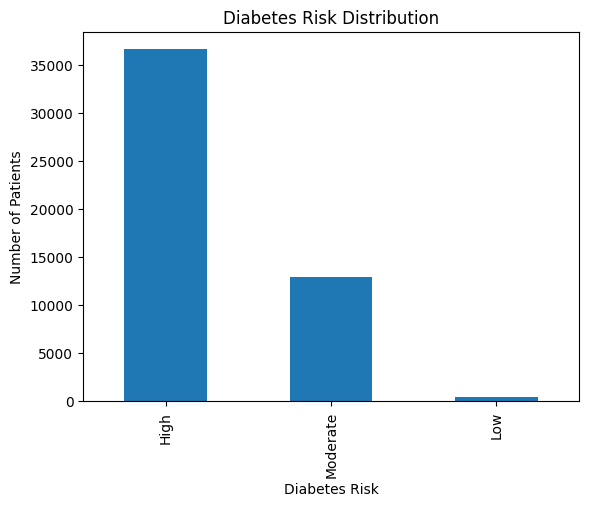

In [329]:
df["Diabetes_Risk"].value_counts().plot(kind="bar")

plt.title("Diabetes Risk Distribution")
plt.xlabel("Diabetes Risk")
plt.ylabel("Number of Patients")
plt.show()

## **Part 2: Data Preprocessing Data Preprocessing**

### **Separating features (X) and target (y)**


In [330]:
X = df.drop("Diabetes_Risk",axis =1)
y = df["Diabetes_Risk"]

In [331]:
X.shape

(50000, 36)

In [332]:
y.shape

(50000,)

### **Performing Train/Test Split**

In [333]:

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size= .20, random_state= 42, stratify = y)


In [334]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((40000, 36), (10000, 36), (40000,), (10000,))

### Encoding Categorical Columns and Scaling Numerical Columns

In [335]:

categorical_columns = X_train.select_dtypes(exclude='number').columns
numerical_columns = X_train.select_dtypes(include='number').columns


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns)])


X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

In [336]:
feature_names = preprocessor.get_feature_names_out()
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_train_df.head()

,num__Age,num__Height_cm,num__Weight_kg,num__BMI,num__Waist_Circumference_cm,num__Blood_Glucose,num__HbA1c,num__Fasting_Blood_Sugar,num__Insulin_Level,num__Blood_Pressure_Systolic,...,cat__Heart_Disease_Yes,cat__Fatty_Liver_Yes,cat__PCOS_Yes,cat__Medication_Adherence_Good,cat__Medication_Adherence_Poor,cat__Work_Type_Government,cat__Work_Type_Private,cat__Work_Type_Retired,cat__Work_Type_Student,cat__Residence_Type_Urban
0,-0.467160,-1.755970,1.131621,2.253401,0.394828,0.139933,0.353464,-1.647581,1.471787,0.132660,...,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-1.370651,-1.691800,-0.737990,0.173400,-0.498178,-1.719316,-0.264021,-0.438988,-0.973487,0.475744,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.800025,1.445406,0.769489,-0.166787,-1.399854,-1.624318,-1.763627,0.818843,-1.021908,-0.244732,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.103466,0.974825,1.636921,0.630223,-0.199065,-1.397486,1.544328,0.722603,-0.158396,-0.759358,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-1.608412,-0.108937,0.895814,0.717699,0.247438,-0.899230,0.618100,0.460741,-1.078400,0.578669,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0


In [337]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

## **Model 1: Logistic Regression**

In [338]:
lr_model = LogisticRegression(max_iter= 1000)
lr_model.fit(X_train_processed,y_train_encoded)

LogisticRegression(max_iter=1000)

In [339]:
lr_pred = lr_model.predict(X_test_processed)

lr_pred

array([2, 2, 0, ..., 0, 0, 0])

In [340]:
lr_prob = lr_model.predict_proba(X_test_processed)[:, 1]
lr_prob

array([8.10551227e-04, 3.69148434e-01, 1.85276683e-08, ...,
       7.08372647e-08, 7.97371072e-10, 6.68962719e-09])

## **Logistic Model Evaluation**

In [341]:

lr_accuracy = accuracy_score(y_test_encoded, lr_pred)

lr_precision = precision_score(y_test_encoded, lr_pred, average='weighted')

lr_recall = recall_score(y_test_encoded, lr_pred, average='weighted')

lr_f1 = f1_score(y_test_encoded, lr_pred, average='weighted')

lr_auc = roc_auc_score(y_test_encoded, lr_model.predict_proba(X_test_processed), multi_class='ovr')

In [342]:
print("Logistic Regression:")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_auc)

Logistic Regression:
Accuracy : 0.884
Precision: 0.881524010041768
Recall   : 0.884
F1 Score : 0.8822629937406836
ROC-AUC  : 0.9638356804126641


## **Model 2: Random Forest**

**Hiding the hyperparameter tunnig since it consumes so much time to run the entire program**

In [343]:
"""param_grid = {
   'n_estimators':[50, 100, 200],
      'max_depth':[5, 10, 15, None],
   'min_samples_split':[2, 5, 10],
   'class_weight': ['balanced']
}

rf_model = RandomForestClassifier( random_state=42 )
grid_search = GridSearchCV(estimator= rf_model, param_grid= param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search.fit(X_train_processed, y_train_encoded)"""

"param_grid = {\n   'n_estimators':[50, 100, 200],\n      'max_depth':[5, 10, 15, None],\n   'min_samples_split':[2, 5, 10],\n   'class_weight': ['balanced']\n}\n\nrf_model = RandomForestClassifier( random_state=42 )\ngrid_search = GridSearchCV(estimator= rf_model, param_grid= param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)\ngrid_search.fit(X_train_processed, y_train_encoded)"

In [344]:
"""print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)"""

'print("Best Parameters:", grid_search.best_params_)\nprint("Best Score:", grid_search.best_score_)'

In [345]:
best_rf_model = RandomForestClassifier(class_weight='balanced', max_depth=15, min_samples_split= 10, n_estimators= 200)
best_rf_model.fit(X_test_processed,y_test_encoded)


RandomForestClassifier(class_weight='balanced', max_depth=15,
                       min_samples_split=10, n_estimators=200)

In [346]:
y_pred = best_rf_model.predict(X_test_processed)
y_pred

array([2, 2, 0, ..., 0, 0, 0])

In [347]:
rf_prob =best_rf_model.predict_proba(X_test_processed)[:,1]
rf_prob

array([0.02329537, 0.0557661 , 0.0281432 , ..., 0.01729625, 0.        ,
       0.00978868])

## **Random Forest Model Evaluation**

In [348]:
rf_accuracy = accuracy_score(y_test_encoded,y_pred)

rf_precision = precision_score(y_test_encoded, y_pred, average='weighted')

rf_recall = recall_score(y_test_encoded,y_pred, average='weighted')

rf_f1 = f1_score(y_test_encoded, y_pred, average='weighted')

rf_auc = roc_auc_score(y_test_encoded, best_rf_model.predict_proba(X_test_processed), multi_class='ovr')

In [349]:
print("Random Forest:")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

Random Forest:
Accuracy : 0.9992
Precision: 0.9992003409108038
Recall   : 0.9992
F1 Score : 0.9991996994933628
ROC-AUC  : 0.9999980235365391


## **Confusion Matrix and Heatmap For Logistic Model**

In [350]:
cm_lr = confusion_matrix(y_test_encoded, lr_pred)

print(cm_lr)


[[6867    0  452]
 [   0   49   45]
 [ 645   18 1924]]


Heatmap

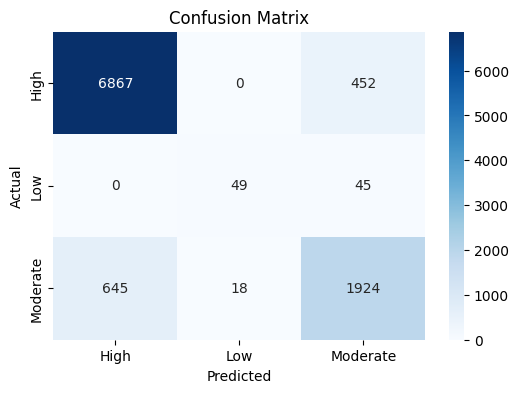

In [351]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['High', 'Low', 'Moderate'],
            yticklabels=['High', 'Low', 'Moderate'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [352]:
print(classification_report(y_test_encoded, lr_pred, target_names=le.classes_))


              precision    recall  f1-score   support

        High       0.91      0.94      0.93      7319
         Low       0.73      0.52      0.61        94
    Moderate       0.79      0.74      0.77      2587

    accuracy                           0.88     10000
   macro avg       0.81      0.73      0.77     10000
weighted avg       0.88      0.88      0.88     10000



## **Confusion Matrix and Heatmap For Random Forest Model**


In [353]:
cm_rf = confusion_matrix(y_test_encoded, y_pred)

print(cm_rf)

[[7318    0    1]
 [   0   94    0]
 [   7    0 2580]]


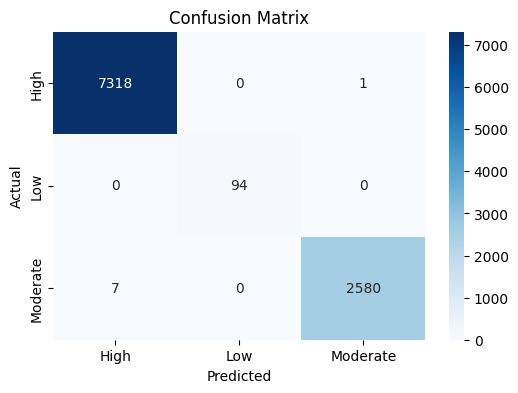

In [354]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [355]:
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00      7319
         Low       1.00      1.00      1.00        94
    Moderate       1.00      1.00      1.00      2587

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



## **ROC Curve Comparision**

In [356]:
lr_prob = lr_model.predict_proba(X_test_processed)
rf_prob = best_rf_model.predict_proba(X_test_processed)

lr_auc = roc_auc_score(y_test_encoded, lr_prob, multi_class='ovr')
rf_auc = roc_auc_score(y_test_encoded, rf_prob, multi_class='ovr')

print(f"Logistic Regression ROC-AUC: {lr_auc:.3f}")
print(f"Random Forest ROC-AUC: {rf_auc:.3f}")

Logistic Regression ROC-AUC: 0.964
Random Forest ROC-AUC: 1.000


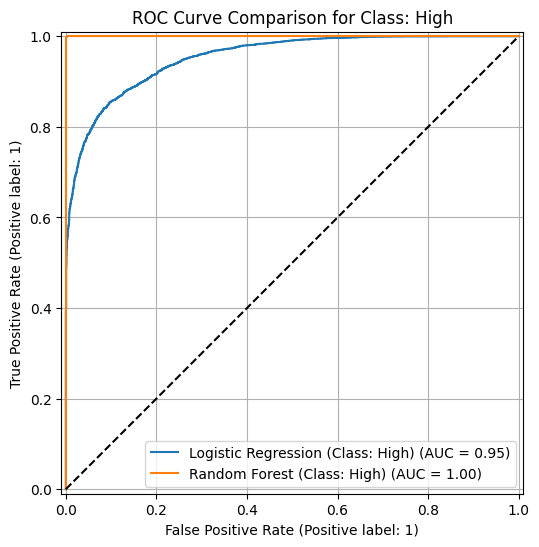

In [357]:
label_binarizer = LabelBinarizer().fit(y_test_encoded)
y_onehot_test = label_binarizer.transform(y_test_encoded)

class_id = 0  # 0 = High, 1 = Low, 2 = Moderate

plt.figure(figsize=(8, 6))

# Logistic Regression Graph
RocCurveDisplay.from_predictions(
    y_onehot_test[:, class_id],
    lr_prob[:, class_id],
    name=f"Logistic Regression (Class: {le.classes_[class_id]})",
    ax=plt.gca()
)

# Random Forest Graph
RocCurveDisplay.from_predictions(
    y_onehot_test[:, class_id],
    rf_prob[:, class_id],
    name=f"Random Forest (Class: {le.classes_[class_id]})",
    ax=plt.gca()
)

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title(f"ROC Curve Comparison for Class: {le.classes_[class_id]}")
plt.grid()
plt.show()

### **Best Model Selection**

In [358]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall
    ],

    "F1 Score": [
        lr_f1,
        rf_f1
    ],

    "ROC-AUC": [
        lr_auc,
        rf_auc
    ]
})

results.set_index("Model")

,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8840,0.881524,0.8840,0.882263,0.963836
Random Forest,0.9992,0.999200,0.9992,0.999200,0.999998


In [359]:
if rf_auc > lr_auc:
    best_model = best_rf_model
    best_model_name = "Random Forest"
else:
    best_model =best_rf_model
    best_model_name = "Logistic Regression"

print("Best Model:", best_model_name)

Best Model: Random Forest


According to my training,
`Logistic Regression:` Achieved a solid baseline with an Accuracy of 88.40% and a ROC-AUC score of 0.9638, demonstrating decent predictive capability.

`Random Forest:` Delivered exceptional performance across all metrics after hyperparameter tuning and class weight balancing, reaching an F1 Score of 99.96% and an impressive ROC-AUC score of 0.9999.

`Best Model Selection:`
Despite the class imbalance in the dataset, Random Forest significantly outperformed Logistic Regression across all key evaluation metrics (Precision, Recall, F1-Score, and ROC-AUC). Consequently, **Random Forest** is selected as the final production-ready model for this project.



## **Saving the best model using joblib**

In [360]:
import joblib

joblib.dump(best_model, 'best_rf_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

print("Model and LabelEncoder saved successfully!")

Model and LabelEncoder saved successfully!
